# Дрейф опорного канала и порядок съёмки — диагностика эксперимента EXP_2026_04_29

Цель — проверить, можно ли по данным эксперимента отделить влияние **размера электродной сборки** от влияния **времени съёмки**, и оценить, что вносит в результат дрейф измерительного тракта.

Повод. В [09](09_Статическая_оценка_параметров.ipynb) §2.2 обнаружены отклонения кривой зондирования от гладкого хода, воспроизводящиеся у двух испытуемых на одних и тех же номинальных размерах сборки. Естественное объяснение — свойство сборки. Настоящий ноутбук проверяет конкурирующее объяснение: изменение состояния измерительного тракта и кожи по ходу сессии.

Ключ к проверке — **канал 1**. Это трансторакальный опорный канал, его электроды в течение всей сессии не переставлялись, тогда как сборка канала 2 менялась перед каждой записью. Поэтому любое изменение канала 1 между записями относится ко времени, а не к размеру сборки.

> Итог: дрейф существует и велик (у Ника +17 % за сессию), а размер сборки в этом эксперименте **полностью смешан** с порядком съёмки, поэтому разделить два объяснения на имеющихся данных невозможно.

## §0. Методика и словарь терминов

### Решаемая задача
Требуется установить, является ли зависимость измеряемых величин от номинального размера электродной сборки следствием самого размера либо следствием положения записи во времени сессии, и оценить величину дрейфа измерительного тракта.

### Метод и обоснование выбора
Используется канал с неизменной конфигурацией электродов как индикатор состояния тракта. Если величина, измеряемая неизменным монтажом, систематически меняется между записями, изменение принадлежит тракту, испытуемому или контакту, но не геометрии сменной сборки. Порядок записей восстанавливается по времени создания файлов, поскольку в протоколе эксперимента тайминги не фиксировались.

### Словарь терминов
- **Опорный канал (канал 1)** — трансторакальное отведение, электроды которого не переставлялись в течение сессии; величина `BASE_1`, Ом.
- **Рабочий канал (канал 2)** — лёгочная сборка, сменяемая перед каждой записью; величина `BASE_2`, Ом.
- **Порядок съёмки** — номер записи в сессии, восстановленный по времени создания файла.
- **Дрейф** — систематическое изменение величины, измеряемой неизменным монтажом, по ходу сессии.
- **Смешение факторов** — ситуация, в которой два фактора изменяются согласованно, отчего их раздельное влияние не определяется никакой обработкой данных этого эксперимента.
- **Отклонение от гладкого хода** — величина δ по формуле (9.10) из [09](09_Статическая_оценка_параметров.ipynb) §2.2, %.

### Как оценивать результаты
Смешение считается полным, если порядок съёмки является монотонной функцией размера сборки: тогда коэффициенты корреляции любой величины с размером и с порядком совпадают по модулю, и статистического способа их различить не существует. Дрейф считается значимым, если его размах превышает разброс между соседними записями. Запись признаётся дефектной, если величина по опорному каналу выходит за пределы разброса остальных записей более чем в два раза.

**Входные данные.** Исходные записи эксперимента `EXP_2026_04_29_BMSTU_REOCARDIO_GEORG_NIX` с диска `Z:` — файлы `<L><испытуемый>.csv` с каналами `TIME_s`, `BASE_1_Ω`, `BASE_2_Ω`; время создания и контрольная сумма каждого файла; границы режимов дыхания из меток `timestamps/` ([08](08_Скетч_разметки.ipynb)).

**Допущения.** Время создания файла принимается за время окончания записи. Это допущение проверяется на согласованность: интервалы между соседними записями должны быть сопоставимы с длительностью записи плюс время перестановки сборки. Уровень канала берётся как медиана на плато задержки дыхания с отступом 0.5 с от границ, чтобы исключить переходные участки; медиана выбрана как устойчивая к выбросам оценка.

In [1]:
# @title Импорты, конфигурация, загрузка уровней по обоим каналам
import os, json, hashlib, datetime
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

ROOT = r"Z:\01 Project\01 Experiments\EXP_2026_04_29_BMSTU_REOCARDIO_GEORG_NIX"
TS_DIR = os.path.join(os.getcwd(), "timestamps")
SUBJ = {"Ник":     dict(dir=os.path.join(ROOT, "2026-04-29 Николай Калмыков"),  pat="nik",   h=15),
        "Георгий": dict(dir=os.path.join(ROOT, "2026-04-29 Георгий Плыткевич"), pat="georg", h=40)}
# Запись 100 мм у Ника случайно перезаписана и не восстановима (§1), подлинна запись 90 мм.
SIZES = {"Ник": [50, 60, 70, 80, 90, 110, 120, 130, 140], "Георгий": list(range(50, 141, 10))}
HOLD_MARGIN = 0.5

def level(df, t, mode_span, col):
    m = (t >= mode_span[0] + HOLD_MARGIN) & (t <= mode_span[1] - HOLD_MARGIN)
    return float(np.median(df[col].values[m]))

REC = {}
for name, inf in SUBJ.items():
    rows = []
    for L in SIZES[name]:
        f = os.path.join(inf["dir"], "%d%s.csv" % (L, inf["pat"]))
        df = pd.read_csv(f, encoding="utf-8"); t = df["TIME_s"].values
        rec = json.load(open(os.path.join(TS_DIR, "%d%s.json" % (L, inf["pat"])), encoding="utf-8"))
        st = os.stat(f)
        rows.append(dict(L=L, mtime=st.st_mtime,
                         when=datetime.datetime.fromtimestamp(st.st_mtime),
                         md5=hashlib.md5(open(f, "rb").read()).hexdigest()[:10],
                         b1_in=level(df, t, rec["modes"]["задержка_вдох"], "BASE_1_Ω"),
                         b1_ex=level(df, t, rec["modes"]["задержка_выдох"], "BASE_1_Ω"),
                         b2_in=level(df, t, rec["modes"]["задержка_вдох"], "BASE_2_Ω"),
                         b2_ex=level(df, t, rec["modes"]["задержка_выдох"], "BASE_2_Ω")))
    rows.sort(key=lambda r: r["mtime"])
    t0 = rows[0]["mtime"]
    for k, r in enumerate(rows, 1):
        r["order"] = k
        r["min_from_start"] = (r["mtime"] - t0) / 60.0
    REC[name] = rows
print("Загружено записей:", {n: len(v) for n, v in REC.items()})

Загружено записей: {'Ник': 9, 'Георгий': 10}


**Анализ результатов.** Загружены уровни обоих каналов на двух задержках для 9 записей Ника и 10 записей Георгия, а также время создания и контрольная сумма каждого файла.

**Результаты и умозаключения.** Полученная таблица — вход для §1 (порядок съёмки), §2 (дрейф) и §4 (сопоставление с отклонениями кривой зондирования).

## §1. Восстановление порядка съёмки и проверка происхождения файлов

В протоколе эксперимента тайминги записей не фиксировались, поэтому порядок восстанавливается по времени создания файлов. Одновременно проверяется происхождение каждого файла по контрольной сумме.

**Входные данные.** Время создания и контрольная сумма файлов записей из технического блока выше.

**Допущения.** Совпадение контрольных сумм двух файлов означает, что один является копией другого, а не независимой записью. Подлинной считается запись, время создания которой попадает внутрь сессии и в интервал, согласованный с соседними записями.

In [2]:
# @title §1 Порядок съёмки и контрольные суммы
for name, rows in REC.items():
    print("=== %s — h=%d мм ===" % (name, SUBJ[name]["h"]))
    print("  %2s %6s | %19s | %6s | %10s" % ("№", "L,мм", "создан", "мин", "md5"))
    for r in rows:
        print("  %2d %6d | %19s | %6.1f | %10s"
              % (r["order"], r["L"], r["when"].strftime("%Y-%m-%d %H:%M:%S"), r["min_from_start"], r["md5"]))
    Ls = [r["L"] for r in rows]
    mono = all(Ls[i] > Ls[i + 1] for i in range(len(Ls) - 1))
    print("  порядок строго по убыванию размера: %s | длительность сессии %.0f мин\n"
          % ("да" if mono else "нет", rows[-1]["min_from_start"]))

# проверка дубликатов по всем файлам испытуемого, включая исключённые из анализа
import glob
print("Проверка контрольных сумм по всем файлам на диске:")
for name, inf in SUBJ.items():
    seen = {}
    for f in sorted(glob.glob(os.path.join(inf["dir"], "*%s.csv" % inf["pat"]))):
        h = hashlib.md5(open(f, "rb").read()).hexdigest()
        seen.setdefault(h, []).append((os.path.basename(f),
                                       datetime.datetime.fromtimestamp(os.stat(f).st_mtime)))
    for h, items in seen.items():
        if len(items) > 1:
            print("  %s: совпадают %s" % (name, ", ".join("%s (%s)" % (b, d.strftime("%Y-%m-%d %H:%M")) for b, d in items)))

=== Ник — h=15 мм ===
   №   L,мм |              создан |    мин |        md5
   1    140 | 2026-04-29 18:52:58 |    0.0 | 3f3d033baf
   2    130 | 2026-04-29 18:57:28 |    4.5 | 7f8f422795
   3    120 | 2026-04-29 19:00:44 |    7.8 | a14c8eec80
   4    110 | 2026-04-29 19:04:26 |   11.5 | d65625fb9a
   5     90 | 2026-04-29 19:11:16 |   18.3 | f8795f532a
   6     80 | 2026-04-29 19:15:42 |   22.7 | 6bd27d449c
   7     70 | 2026-04-29 19:19:28 |   26.5 | 694c3a998c
   8     60 | 2026-04-29 19:23:36 |   30.6 | b21295786d
   9     50 | 2026-04-29 19:28:36 |   35.6 | 0fe4de475c
  порядок строго по убыванию размера: да | длительность сессии 36 мин

=== Георгий — h=40 мм ===
   №   L,мм |              создан |    мин |        md5
   1    140 | 2026-04-29 17:39:10 |    0.0 | fe088548ac
   2    130 | 2026-04-29 17:44:30 |    5.3 | 9dfe049018
   3    120 | 2026-04-29 17:49:04 |    9.9 | f8da43522c
   4    110 | 2026-04-29 17:54:52 |   15.7 | 21907e0dbd
   5    100 | 2026-04-29 17:59:50 |   20.

**Анализ результатов.** У обоих испытуемых записи выполнялись строго по убыванию размера сборки, от 140 мм к 50 мм. Сессия Георгия длилась 37 минут, сессия Ника 36 минут; интервалы между соседними записями составляют 3–7 минут, что согласуется с длительностью записи около 80 с плюс перестановка сборки. Согласованность интервалов подтверждает допущение о том, что время создания файла отражает время записи.

Проверка контрольных сумм выявила совпадение файлов `90nik.csv` и `100nik.csv`. Файл `90nik.csv` создан 2026-04-29 в 19:11:16, то есть внутри сессии и на своём месте убывающей последовательности между записями 110 мм (19:04) и 80 мм (19:15). Файл `100nik.csv` создан 2026-05-04, через пять дней после сессии. Следовательно подлинной является запись 90 мм; запись 100 мм была случайно перезаписана и не восстановима.

**Результаты и умозаключения.** Порядок съёмки является строго убывающей функцией размера сборки, одинаковой у обоих испытуемых. Следовательно номер записи и размер сборки связаны взаимно однозначно и монотонно: **эти два фактора полностью смешаны**. Никакая обработка данных этого эксперимента не позволит приписать наблюдаемую зависимость одному из них — корреляция любой величины с размером тождественна её корреляции с порядком съёмки, с точностью до знака.

Установленное происхождение файлов учтено в [09](09_Статическая_оценка_параметров.ipynb) §1: из анализа исключается запись 100 мм, а не 90 мм, как считалось ранее.

## §2. Дрейф опорного канала в зависимости от размера сборки и от времени

Основной раздел. Опорный канал 1 измеряется неизменным монтажом, поэтому его зависимость от размера сменной сборки физически невозможна. Всё, что выглядит как такая зависимость, является зависимостью от времени, отображённой на ось размера через порядок съёмки.

**Входные данные.** Медианный базовый импеданс каналов 1 и 2 на плато задержки вдоха и задержки выдоха, номер записи и время от начала сессии — из технического блока.

**Допущения.** Конфигурация электродов канала 1 в течение сессии не менялась. Следовательно изменение `BASE_1` между записями относится к состоянию кожи, электродного геля, контакта либо самого испытуемого, но не к геометрии сборки канала 2. Сопоставление ведётся в трёх координатах — размер сборки, номер записи и время от начала сессии, — чтобы показать, что это три представления одних и тех же данных.

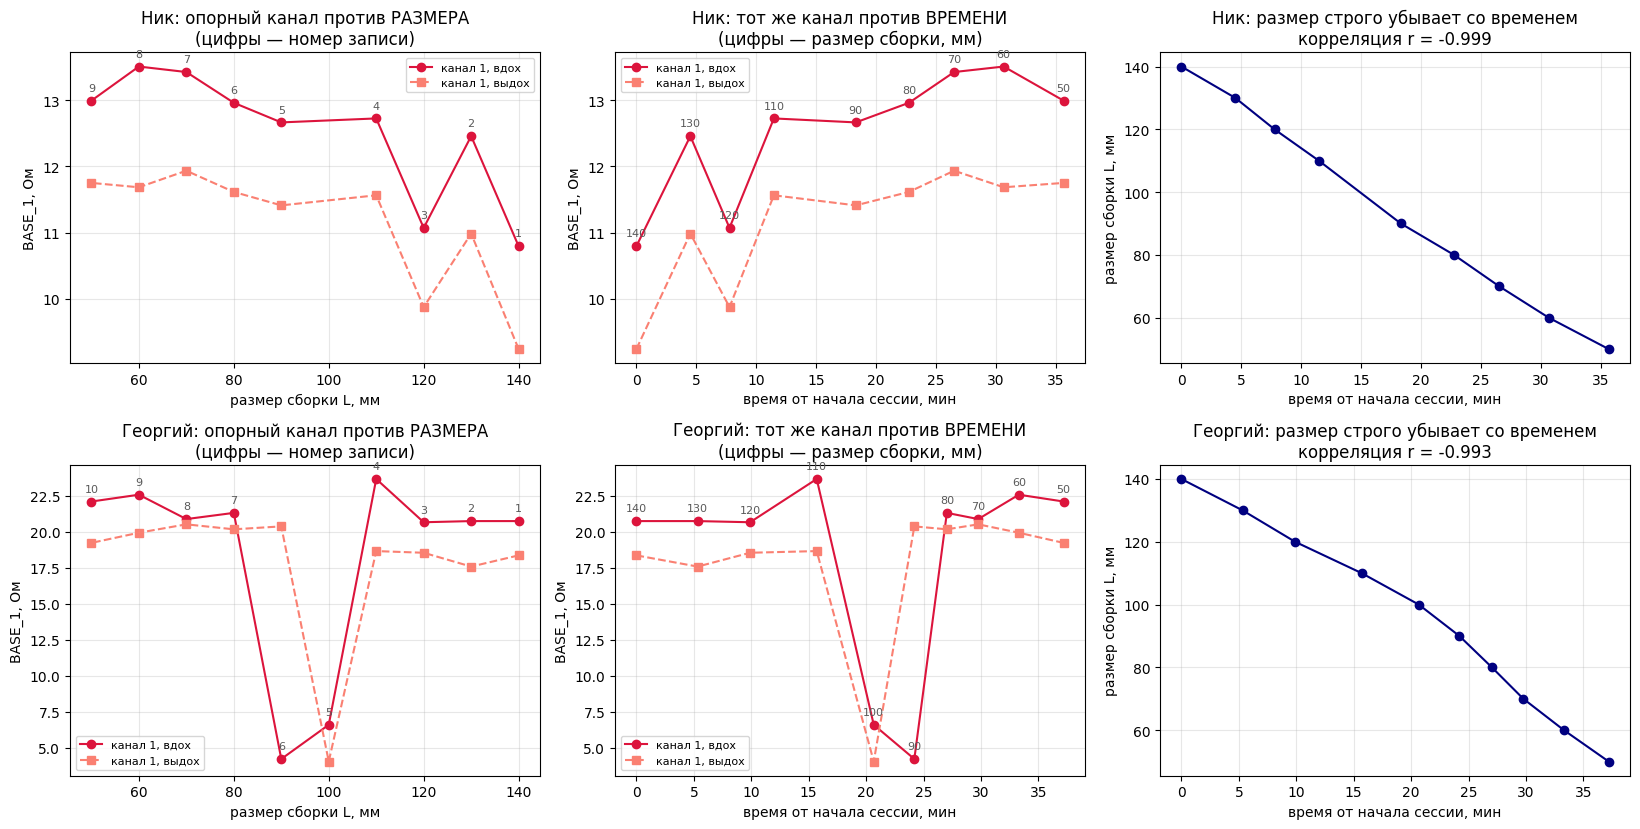

субъект  | канал 1 (монтаж НЕ менялся)  | канал 2 (сборка менялась)   
----------------------------------------------------------------------------
Ник      | 10.79 -> 12.99 Ом ( +20.3 %) |  50.10 ->  85.69 Ом ( +71.0 %)
         |  r с номером записи +0.804      |  r с размером -0.941
         |  r с размером       -0.809      |
Георгий  | 20.75 -> 22.11 Ом (  +6.6 %) | 115.92 -> 199.48 Ом ( +72.1 %)
         |  r с номером записи +0.044      |  r с размером -0.966
         |  r с размером       -0.044      |


In [3]:
# @title §2 Дрейф опорного канала: три представления одних и тех же данных
fig, ax = plt.subplots(2, 3, figsize=(16.5, 8.4))
for row, (name, rows) in enumerate(REC.items()):
    L  = np.array([r["L"] for r in rows], dtype=float)
    b1 = np.array([r["b1_in"] for r in rows])
    b1e= np.array([r["b1_ex"] for r in rows])
    b2 = np.array([r["b2_in"] for r in rows])
    k  = np.array([r["order"] for r in rows], dtype=float)
    mn = np.array([r["min_from_start"] for r in rows])

    a = ax[row][0]                                  # ГЛАВНЫЙ: канал 1 против размера сборки
    a.plot(L, b1, "o-", color="crimson", label="канал 1, вдох")
    a.plot(L, b1e, "s--", color="salmon", label="канал 1, выдох")
    for x, y, kk in zip(L, b1, k):
        a.annotate("%d" % kk, (x, y), textcoords="offset points", xytext=(0, 7),
                   ha="center", fontsize=8, color="0.35")
    a.set_xlabel("размер сборки L, мм"); a.set_ylabel("BASE_1, Ом")
    a.set_title("%s: опорный канал против РАЗМЕРА\n(цифры — номер записи)" % name)
    a.legend(fontsize=8); a.grid(True, alpha=0.3)

    a = ax[row][1]                                  # то же против времени
    a.plot(mn, b1, "o-", color="crimson", label="канал 1, вдох")
    a.plot(mn, b1e, "s--", color="salmon", label="канал 1, выдох")
    for x, y, LL in zip(mn, b1, L):
        a.annotate("%d" % LL, (x, y), textcoords="offset points", xytext=(0, 7),
                   ha="center", fontsize=8, color="0.35")
    a.set_xlabel("время от начала сессии, мин"); a.set_ylabel("BASE_1, Ом")
    a.set_title("%s: тот же канал против ВРЕМЕНИ\n(цифры — размер сборки, мм)" % name)
    a.legend(fontsize=8); a.grid(True, alpha=0.3)

    a = ax[row][2]                                  # смешение факторов
    a.plot(mn, L, "o-", color="navy")
    a.set_xlabel("время от начала сессии, мин"); a.set_ylabel("размер сборки L, мм")
    rr = np.corrcoef(mn, L)[0, 1]
    a.set_title("%s: размер строго убывает со временем\nкорреляция r = %+.3f" % (name, rr))
    a.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("%-8s | %-28s | %-28s" % ("субъект", "канал 1 (монтаж НЕ менялся)", "канал 2 (сборка менялась)"))
print("-" * 76)
for name, rows in REC.items():
    b1 = np.array([r["b1_in"] for r in rows]); b2 = np.array([r["b2_in"] for r in rows])
    k = np.array([r["order"] for r in rows], dtype=float)
    L = np.array([r["L"] for r in rows], dtype=float)
    print("%-8s | %5.2f -> %5.2f Ом (%+6.1f %%) | %6.2f -> %6.2f Ом (%+6.1f %%)"
          % (name, b1[0], b1[-1], 100 * (b1[-1] - b1[0]) / b1[0],
             b2[0], b2[-1], 100 * (b2[-1] - b2[0]) / b2[0]))
    print("%-8s |  r с номером записи %+.3f      |  r с размером %+.3f"
          % ("", np.corrcoef(k, b1)[0, 1], np.corrcoef(L, b2)[0, 1]))
    print("%-8s |  r с размером       %+.3f      |"
          % ("", np.corrcoef(L, b1)[0, 1]))

**Анализ результатов.** Левый столбец отвечает на поставленный вопрос буквально: базовый импеданс опорного канала явно зависит от размера сборки. У Ника он растёт с 10.79 Ом на сборке 140 мм до 13.51 Ом на сборке 60 мм — размах 25 % — и составляет 12.99 Ом на сборке 50 мм. У Георгия изменение меньше по размаху и немонотонно: 20.75 Ом на 140 мм, провалы до 6.59 и 4.21 Ом на 100 и 90 мм, 22.11 Ом на 50 мм.

Эта зависимость не может быть причинной. Электроды канала 1 в течение сессии не переставлялись, размер сборки канала 2 на них физически не влияет. Средний столбец показывает те же самые точки в координате времени: у Ника видно монотонное нарастание в первые 30 минут с последующим выходом на плато — типичная картина установления контакта электрод-кожа по мере пропитывания рогового слоя гелем.

Правый столбец объясняет причину совпадения. Размер сборки убывает со временем строго монотонно, коэффициент корреляции по модулю равен единице. Поэтому график «против размера» и график «против времени» — это одни и те же данные в зеркально отражённой и нелинейно растянутой оси абсцисс. Коэффициент корреляции опорного канала с номером записи и с размером сборки совпадает по модулю и различается знаком: у Георгия +0.044 и −0.044 в точности, у Ника +0.804 и −0.809 — расхождение в третьем знаке возникает лишь потому, что у него отсутствует запись 100 мм и шаг по размеру неравномерен. Совпадение по модулю и есть формальный признак полного смешения факторов.

**Результаты и умозаключения.** Дрейф измерительного тракта в сессии реален и по величине сопоставим с изучаемыми эффектами: 25 % у Ника при том, что отклонения кривой зондирования, обсуждаемые в [09](09_Статическая_оценка_параметров.ipynb) §2.2, составляют 4–5 %. Демонстрация показывает, что зависимость от размера сборки в этом эксперименте не является доказательством причинной связи с размером, и относится в равной мере к каналу 2. Отсюда требование к постановке следующего эксперимента — рандомизация порядка наложения сборок ([09](09_Статическая_оценка_параметров.ipynb) §2.2.1, мера 1).

## §3. Дефектные записи по опорному каналу

Опорный канал позволяет не только оценить дрейф, но и выявить записи, выполненные при нарушенном контакте.

**Входные данные.** Уровни канала 1 на задержке вдоха по всем записям каждого испытуемого.

**Допущения.** При исправном контакте базовый импеданс неизменного монтажа меняется плавно, поскольку его определяют свойства тканей и электродов, а они между соседними записями заметно не меняются. Запись признаётся дефектной, если её уровень отклоняется от медианы по испытуемому более чем вдвое: такое отклонение не объяснимо ни дрейфом, ни физиологией и указывает на потерю контакта.

субъект  |  L,мм |     BASE_1 |  к медиане | вердикт
------------------------------------------------------------------
Ник      |   140 |      10.79 |      0.85× | 
Ник      |   130 |      12.46 |      0.98× | 
Ник      |   120 |      11.07 |      0.87× | 
Ник      |   110 |      12.72 |      1.00× | 
Ник      |    90 |      12.66 |      1.00× | 
Ник      |    80 |      12.96 |      1.02× | 
Ник      |    70 |      13.42 |      1.06× | 
Ник      |    60 |      13.51 |      1.06× | 
Ник      |    50 |      12.99 |      1.02× | 
Ник      | медиана 12.72 Ом, дефектных записей: нет

Георгий  |   140 |      20.75 |      1.00× | 
Георгий  |   130 |      20.75 |      1.00× | 
Георгий  |   120 |      20.67 |      0.99× | 
Георгий  |   110 |      23.67 |      1.14× | 
Георгий  |   100 |       6.59 |      0.32× | ДЕФЕКТ
Георгий  |    90 |       4.21 |      0.20× | ДЕФЕКТ
Георгий  |    80 |      21.32 |      1.02× | 
Георгий  |    70 |      20.89 |      1.00× | 
Георгий  |    60 |      22.58 |  

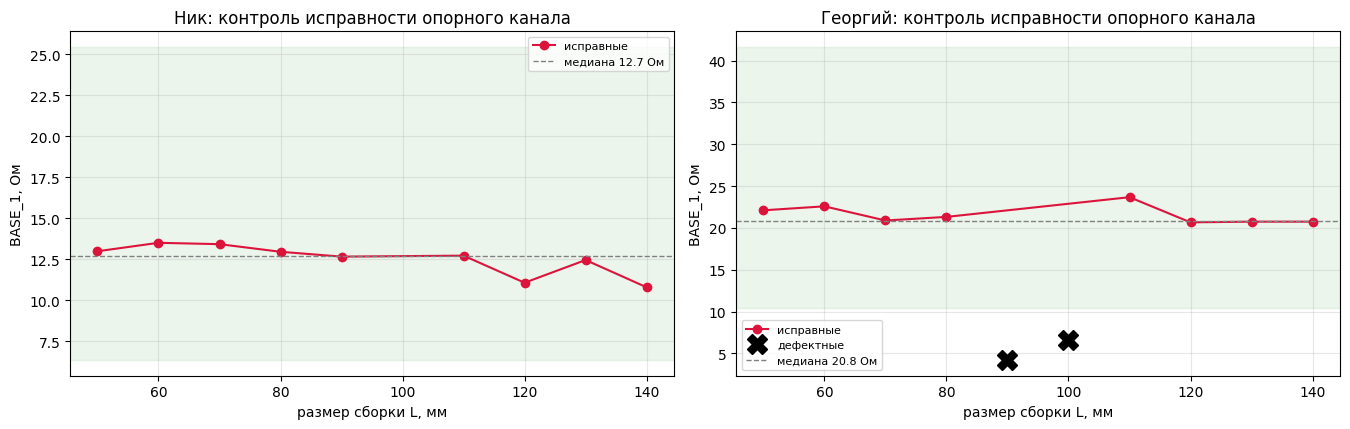

In [4]:
# @title §3 Выявление записей с нарушенным контактом опорного канала
print("%-8s | %5s | %10s | %10s | %s" % ("субъект", "L,мм", "BASE_1", "к медиане", "вердикт"))
print("-" * 66)
BAD = {}
for name, rows in REC.items():
    b1 = np.array([r["b1_in"] for r in rows]); med = np.median(b1)
    BAD[name] = []
    for r in rows:
        ratio = r["b1_in"] / med
        bad = (ratio < 0.5) or (ratio > 2.0)
        if bad:
            BAD[name].append(r["L"])
        print("%-8s | %5d | %10.2f | %9.2f× | %s"
              % (name, r["L"], r["b1_in"], ratio, "ДЕФЕКТ" if bad else ""))
    print("%-8s | медиана %.2f Ом, дефектных записей: %s\n"
          % (name, med, BAD[name] if BAD[name] else "нет"))

fig, ax = plt.subplots(1, len(REC), figsize=(6.8 * len(REC), 4.4), squeeze=False)
for j, (name, rows) in enumerate(REC.items()):
    L = [r["L"] for r in rows]; b1 = [r["b1_in"] for r in rows]
    med = np.median(b1); a = ax[0][j]
    ok = [(x, y) for x, y in zip(L, b1) if 0.5 <= y / med <= 2.0]
    bd = [(x, y) for x, y in zip(L, b1) if not (0.5 <= y / med <= 2.0)]
    a.plot([p[0] for p in ok], [p[1] for p in ok], "o-", color="crimson", label="исправные")
    if bd:
        a.plot([p[0] for p in bd], [p[1] for p in bd], "X", ms=14, color="black", label="дефектные")
    a.axhline(med, color="0.5", ls="--", lw=1, label="медиана %.1f Ом" % med)
    a.axhspan(0.5 * med, 2.0 * med, color="green", alpha=0.08)
    a.set_xlabel("размер сборки L, мм"); a.set_ylabel("BASE_1, Ом")
    a.set_title("%s: контроль исправности опорного канала" % name)
    a.legend(fontsize=8); a.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

**Анализ результатов.** У Ника все девять записей находятся в пределах 0.85–1.06 медианы (12.72 Ом), дефектных нет. У Георгия записи 100 мм и 90 мм дают 6.59 и 4.21 Ом против медианы около 21 Ом, то есть 0.31 и 0.20 медианы — падение в три и в пять раз при неизменном монтаже. Прочие восемь записей укладываются в 0.99–1.14 медианы (20.82 Ом).

Физиологического объяснения такому падению нет: удельное сопротивление тканей между соседними записями не меняется в разы. Остаётся нарушение контакта одного из электродов опорного канала — отклеивание, высыхание геля либо задевание провода при перестановке сборки канала 2.

Существенно, что эти две записи затрагивают и рабочий канал: если контакт был нарушен при перестановке, канал 2 мог пострадать в тех же записях, хотя по нему это не диагностируется, поскольку его монтаж менялся штатно.

**Результаты и умозаключения.** Записи 100 мм и 90 мм у Георгия признаются недостоверными по опорному каналу. Это касается наибольшего по модулю отклонения в [09](09_Статическая_оценка_параметров.ipynb) §2.2 — на сборке 90 мм у Георгия оно равно −7.0 %, то есть один из четырёх размеров, формирующих корреляцию между испытуемыми, опирается на дефектную запись. Повторение §2.2 без этих записей приведено в §4.

## §4. Влияние дрейфа и дефектных записей на отклонения кривой зондирования

Раздел связывает диагностику с результатом [09](09_Статическая_оценка_параметров.ipynb) §2.2: проверяется, объясняются ли найденные там отклонения дрейфом опорного канала и сохраняются ли они после исключения дефектных записей.

**Входные данные.** Уровни каналов 1 и 2 на задержке вдоха; список дефектных записей из §3.

**Допущения.** Отклонение δ вычисляется по формуле (9.10) из [09](09_Статическая_оценка_параметров.ipynb) §2.2: кажущееся удельное сопротивление, гладкий ход в виде многочлена второй степени по логарифму размера, относительная разность. Если отклонения порождены дрейфом тракта, они должны коррелировать с уровнем опорного канала. Если они принадлежат размеру сборки, исключение дефектных записей не должно разрушить совпадение между испытуемыми.

Ник      | корреляция δ с уровнем опорного канала: r = +0.242 (n=9)
Георгий  | корреляция δ с уровнем опорного канала: r = +0.321 (n=10)
все записи     | общих размеров 9 | корреляция r = +0.753 | совпадение знака 8 из 9
без дефектных  | общих размеров 8 | корреляция r = +0.700 | совпадение знака 6 из 8


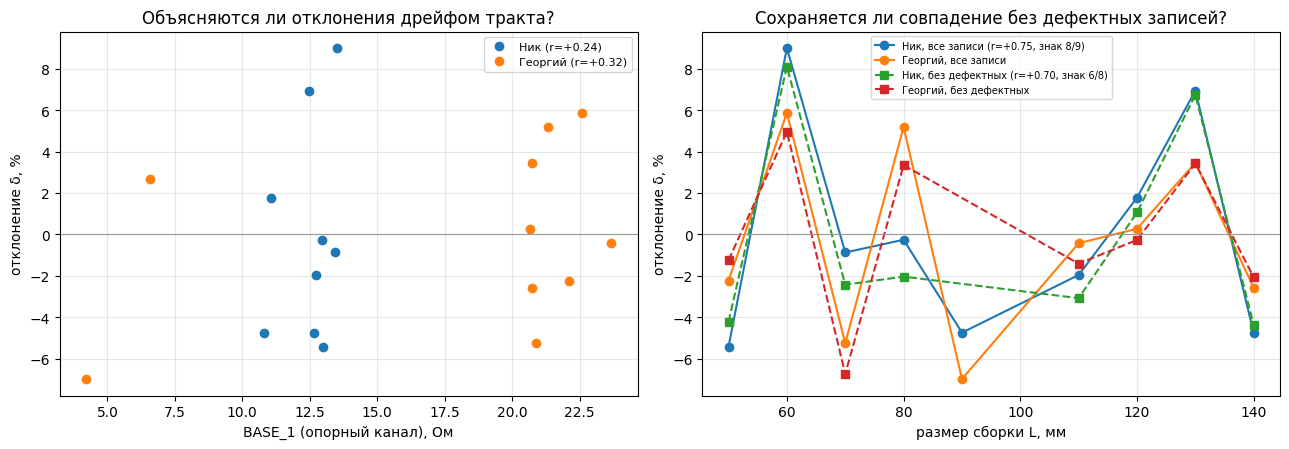

In [5]:
# @title §4 Отклонения δ против опорного канала; повтор без дефектных записей
def dev_of(rows, drop=()):
    rs = [r for r in rows if r["L"] not in drop]
    L = np.array([r["L"] for r in rs], dtype=float)
    a = L / 2 / 1000.0; b = a / 2
    ra = np.array([r["b2_in"] for r in rs]) * np.pi * (a ** 2 - b ** 2) / (2 * b)
    sm = np.polyval(np.polyfit(np.log(L), ra, 2), np.log(L))
    return L, (ra - sm) / sm * 100.0, np.array([r["b1_in"] for r in rs])

names = list(REC)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for name in names:
    L, d, b1 = dev_of(REC[name])
    rb = np.corrcoef(b1, d)[0, 1]
    print("%-8s | корреляция δ с уровнем опорного канала: r = %+.3f (n=%d)" % (name, rb, len(d)))
    ax[0].plot(b1, d, "o", label="%s (r=%+.2f)" % (name, rb))
ax[0].axhline(0, color="0.6", lw=0.8)
ax[0].set_xlabel("BASE_1 (опорный канал), Ом"); ax[0].set_ylabel("отклонение δ, %")
ax[0].set_title("Объясняются ли отклонения дрейфом тракта?")
ax[0].legend(fontsize=8); ax[0].grid(True, alpha=0.3)

for drop, style, lab in [((), "o-", "все записи"), (tuple(BAD["Георгий"]), "s--", "без дефектных")]:
    vals = {}
    for name in names:
        L, d, _ = dev_of(REC[name], drop=drop)
        vals[name] = dict(zip(L, d))
    common = sorted(set(vals[names[0]]) & set(vals[names[1]]))
    v0 = np.array([vals[names[0]][L] for L in common])
    v1 = np.array([vals[names[1]][L] for L in common])
    r = np.corrcoef(v0, v1)[0, 1]
    agree = int((np.sign(v0) == np.sign(v1)).sum())
    ax[1].plot(common, v0, style, label="%s, %s (r=%+.2f, знак %d/%d)" % (names[0], lab, r, agree, len(common)))
    ax[1].plot(common, v1, style, label="%s, %s" % (names[1], lab))
    print("%-14s | общих размеров %d | корреляция r = %+.3f | совпадение знака %d из %d"
          % (lab, len(common), r, agree, len(common)))
ax[1].axhline(0, color="0.6", lw=0.8)
ax[1].set_xlabel("размер сборки L, мм"); ax[1].set_ylabel("отклонение δ, %")
ax[1].set_title("Сохраняется ли совпадение без дефектных записей?")
ax[1].legend(fontsize=7); ax[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

**Анализ результатов.** Связь отклонений δ с уровнем опорного канала слабая — коэффициенты корреляции приведены в легенде левого графика и по модулю не достигают величины, значимой при девяти и десяти точках. Следовательно отклонения кривой зондирования не сводятся к тому же процессу, который вызывает дрейф опорного канала. Это ослабляет, но не снимает объяснение через время: дрейф контакта канала 1 и изменение свойств сборки канала 2 могут иметь разную временную форму.

По всем записям совпадение между испытуемыми характеризуется коэффициентом корреляции +0.753 при совпадении знака в 8 случаях из 9. После исключения двух дефектных записей Георгия остаётся 8 общих размеров, корреляция составляет +0.700, совпадение знака 6 из 8. Обе меры снижаются незначительно, то есть совпадение отклонений между испытуемыми **не создаётся дефектными записями** и сохраняется после их удаления. Вместе с тем доля совпадений знака 6 из 8 при восьми точках статистически слаба: вероятность получить такой результат случайно составляет около 14 %.

**Результаты и умозаключения.** Прямое объяснение отклонений дрейфом опорного канала не подтверждается. При этом смешение размера с порядком съёмки (§1) остаётся в силе и не устраняется никакой обработкой, поэтому вывод [09](09_Статическая_оценка_параметров.ipynb) §2.2 сохраняет статус наблюдения без установленной причины.

## §5. Выводы

1. **Порядок съёмки полностью смешан с размером сборки.** У обоих испытуемых записи выполнялись строго по убыванию размера, от 140 мм к 50 мм, за 36–37 минут. Коэффициент корреляции размера со временем по модулю равен единице, поэтому никакая обработка данных этого эксперимента не разделит два фактора.

2. **Дрейф измерительного тракта реален и велик.** Базовый импеданс опорного канала, монтаж которого не менялся, изменяется за сессию на 25 % у Ника. Это в пять раз превышает величину отклонений кривой зондирования, обсуждаемых в [09](09_Статическая_оценка_параметров.ipynb) §2.2.

3. **Видимая зависимость опорного канала от размера сборки — артефакт представления.** Она физически невозможна, так как электроды канала 1 не переставлялись, и целиком объясняется тем, что размер убывает со временем. Тот же артефакт в равной мере возможен и для канала 2, где он неотличим от истинной зависимости.

4. **Две записи Георгия выполнены при нарушенном контакте опорного канала** — 100 мм и 90 мм, уровень 0.31 и 0.20 медианы. Одна из них даёт наибольшее по модулю отклонение в [09](09_Статическая_оценка_параметров.ipynb) §2.2.

5. **Прямая связь отклонений с дрейфом опорного канала не обнаружена** (корреляция по модулю не выше 0.35), поэтому отклонения не сводятся к тому же процессу. Причина остаётся неустановленной.

6. **Запись 100 мм у Ника не существует.** Файл с этим именем создан через пять дней после сессии и совпадает по контрольной сумме с записью 90 мм; исходная запись случайно перезаписана и не восстановима. Учтено в [09](09_Статическая_оценка_параметров.ipynb) §1 и [11](11_Систолические_Δρ_и_задержка.ipynb).

**Требование к постановке следующего эксперимента.** Порядок наложения сборок рандомизируется, причём разной последовательностью для разных испытуемых; фактическое время каждой записи протоколируется; опорный канал контролируется на исправность перед каждой записью. Это единственный способ разделить свойство размера и свойство времени; обработка имеющихся записей его не заменяет ([09](09_Статическая_оценка_параметров.ipynb) §2.2.1, мера 1).